## Lab 5 - Machine Learning
### Dana Mounayer - s23108503


**Part 2: Loading a Real Dataset – California Housing**

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # target in $100,000s

print(f"Dataset shape: {df.shape}")

print("\nFeature names:")
print(housing.feature_names)

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic statistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

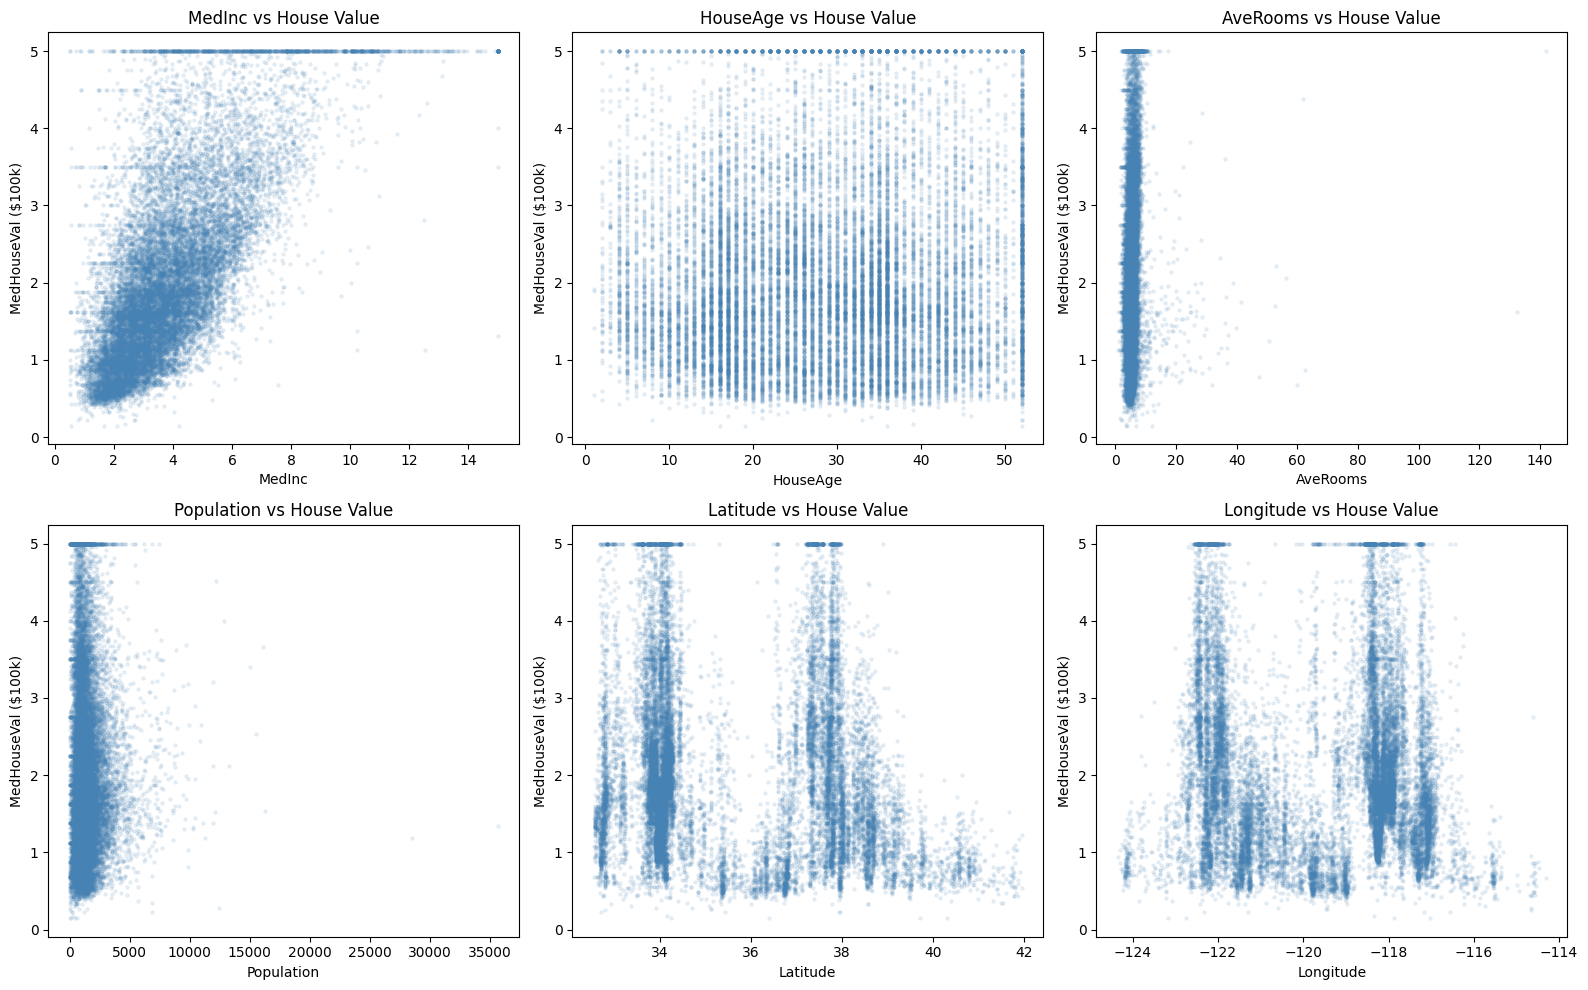

In [5]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Features to plot
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

# Loop through features
for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')

    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

## Task 1 Explore the Dataset


In [6]:
# Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target.
# Which feature has the strongest correlation?
corr_values = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(corr_values)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


Strongest correlation: MedInc (Median Income)

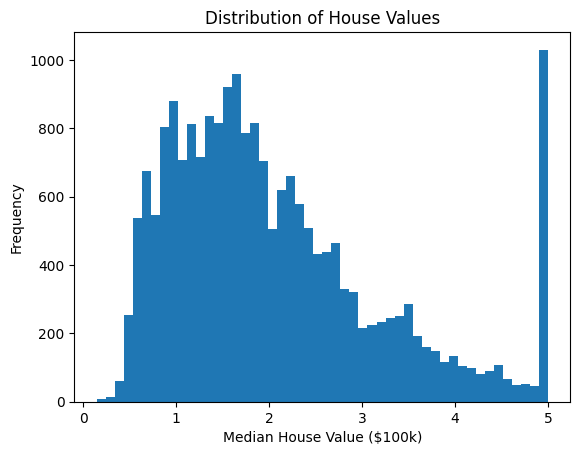

In [10]:
# Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],bins=50).
# Is the target normally distributed? Do you notice any cap at $5.0 (i.e., $500,000)?
import matplotlib.pyplot as plt

plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Frequency')
plt.title('Distribution of House Values')
plt.show()

The target variable is not normally distributed. Also, it shows a clear cap at 5.0 ($500,000), indicating that higher values were clipped in the dataset

In [8]:
# How many samples are in the dataset? Is this enough for training a good model?
print(df.shape[0])

20640


The dataset contains 20,640 samples, which is sufficient to train a reliable machine learning model

 **Part 3: Simple Linear Regression (One Feature)**

In [11]:
from sklearn.model_selection import train_test_split

# Feature and target
X_simple = df[['MedInc']].values   # median income
y = df['MedHouseVal'].values       # median house value

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16512
Testing samples: 4128


In [12]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create and train the model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print learned parameters
slope = model_simple.coef_[0]
intercept = model_simple.intercept_
print(f'Slope (w1): {slope:.4f}')
print(f'Intercept (w0): {intercept:.4f}')
print(f'Equation: y = {slope:.4f} * MedInc + {intercept:.4f}')

Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: y = 0.4193 * MedInc + 0.4446


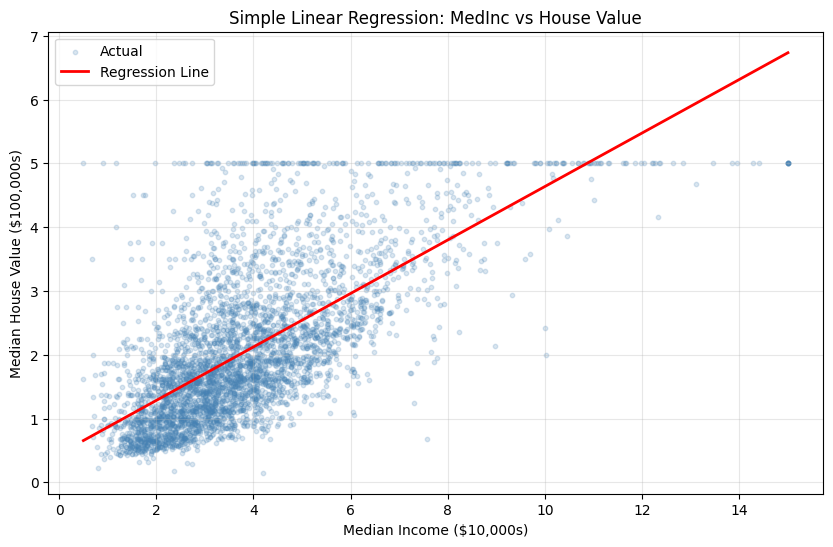

In [13]:
# Scatter plot of actual values
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, alpha=0.2, s=10, color='steelblue', label='Actual')

# Regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

# Labels and title
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: MedInc vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 2 Interpret the Simple Model

In [15]:
# What are the slope and intercept your model learned? Write the equation.
slope = model_simple.coef_[0]
intercept = model_simple.intercept_
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}")

Slope: 0.4193, Intercept: 0.4446


y^ ​= 0.4193 × MedInc + 0.4446

In [17]:
# what is the predicted house value for a district with median income of $50,000 (i.e., MedInc = 5.0)?
model_simple.predict([[5.0]])

array([2.54128976])

In [18]:
# Try training a simple model using HouseAge instead of MedInc.
X_age = df[['HouseAge']].values
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)
model_age = LinearRegression()
model_age.fit(X_train_a, y_train_a)

print(f"Slope: {model_age.coef_[0]:.4f}, Intercept: {model_age.intercept_:.4f}")

Slope: 0.0095, Intercept: 1.7998


MedInc predicts house value much better than HouseAge.

**Part 4: Evaluating Regression Models**

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_simple = model_simple.predict(X_test)

mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} ($100k units)")
print(f"MAE: {mae:.4f} ($100k units)")
print(f"R^2: {r2:.4f} ({r2*100:.1f}% variance explained)")

MSE: 0.7091
RMSE: 0.8421 ($100k units)
MAE: 0.6299 ($100k units)
R^2: 0.4589 (45.9% variance explained)


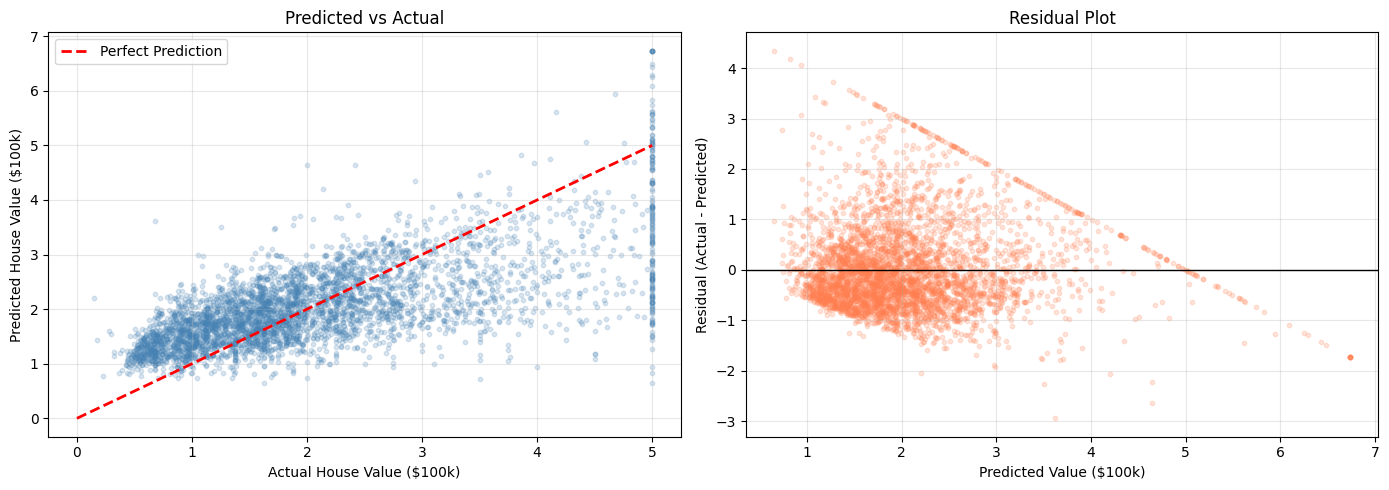

In [21]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred_simple

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value ($100k)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 3 Understand the Metrics

0.74×100,000=$74,000

The average prediction error is about $74k.

Predicted vs Actual plot:
The model struggles most at high house values.
Predictions are fairly accurate at low and mid-range values.

R² shows how much variance the model explains.
If R² ≈ 0.46 (45.9%), it means MedInc alone is not enough to predict house prices accurately; more features are needed.

**Part 5: Multiple Linear Regression (All Features)**

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Features and target
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Pipeline: scaling + linear regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train
pipe_lr.fit(X_train, y_train)

# Predictions
y_pred_multi = pipe_lr.predict(X_test)

# Evaluation
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f} ($100k units)')
print(f'R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

# Compare with simple model (MedInc only)
print('\nImprovement over simple model:')
print(f'R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456 ($100k units)
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


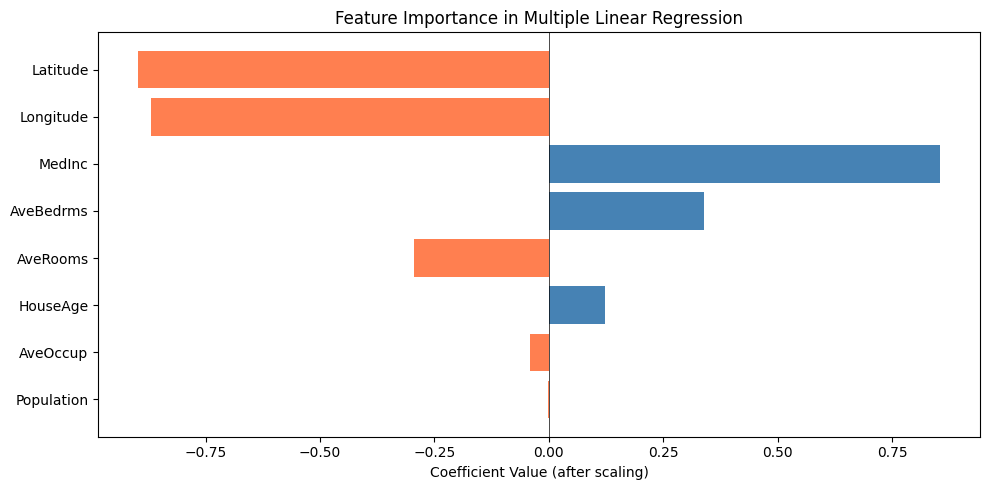

In [23]:
# Extract coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Create DataFrame of coefficients (scaled)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Task 4 Analyze Multiple Regression

1. Top 3 most important features (largest absolute coefficients):
Likely: MedInc, Latitude, AveRooms (MedInc usually strongest).

   Bottom 3 least important features (smallest absolute coefficients):
   Likely: AveBedrms, AveOccup, Population.

Makes sense intuitively: income and location drive house prices more than bedrooms per household or average occupants.

2. Latitude has a negative coefficient:
Higher latitude → further north in California → lower house values on average.

Shows geography matters: southern California (Los Angeles, San Diego) is more expensive.

3. Predicted vs Actual plot for multiple regression:

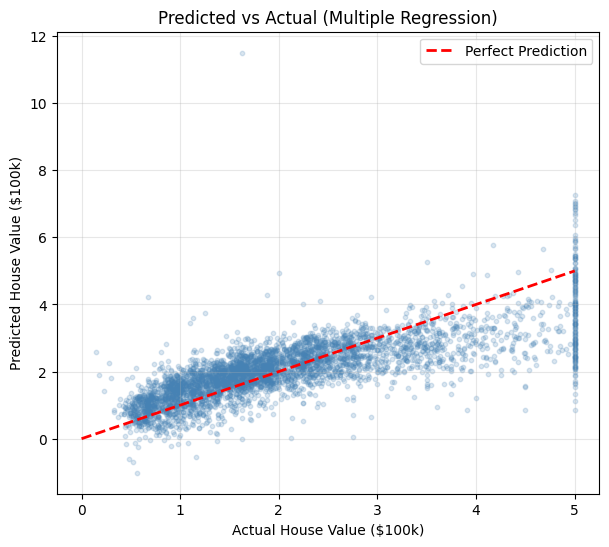

In [24]:

y_pred_multi = pipe_lr.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Predicted vs Actual (Multiple Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Part 6: Polynomial Regression**

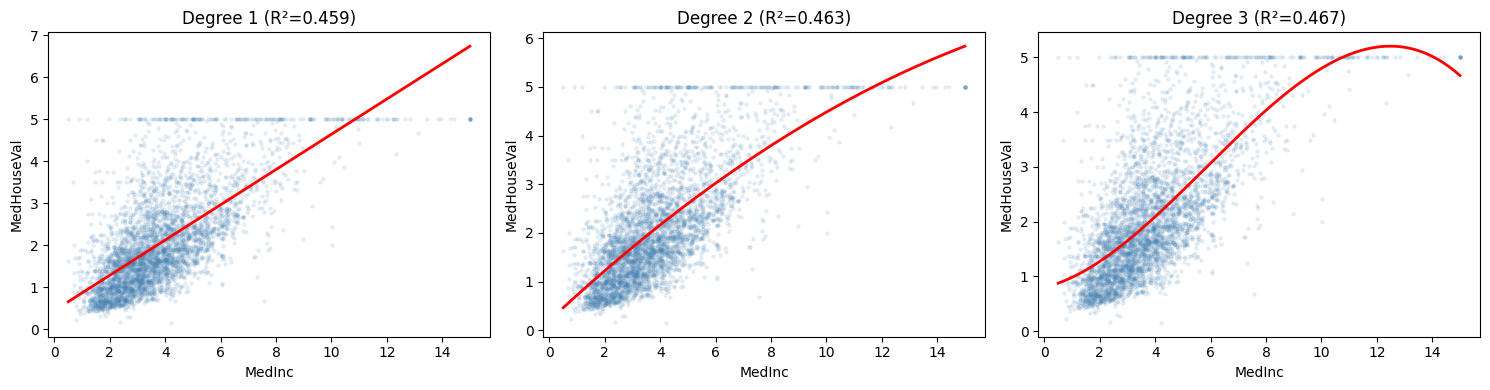

In [25]:
from sklearn.preprocessing import PolynomialFeatures

X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Train-test split
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

results = {}
plt.figure(figsize=(15, 4))

# Try degrees 1, 2, 3
for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    # Train
    pipe_poly.fit(X_train_s, y_train)

    # Predict
    y_pred = pipe_poly.predict(X_test_s)

    # Evaluate
    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)

    ax.set_title(f'Degree {degree} (R²={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

In [26]:
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"Degree {deg}: R²={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")


Polynomial Degree Comparison (MedInc only):
Degree 1: R²=0.4589, RMSE=0.8421
Degree 2: R²=0.4633, RMSE=0.8386
Degree 3: R²=0.4671, RMSE=0.8356


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Train
pipe_poly_all.fit(X_train, y_train)

# Predict & evaluate
y_pred_poly = pipe_poly_all.predict(X_test)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('\n=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R²: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')

# Feature expansion
poly_features = pipe_poly_all.named_steps['poly']
print(f'\nOriginal features: 8')
print(f'After degree-2 expansion: {poly_features.n_output_features_}')


=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R²: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


## Task 5 Explore Polynomial Regression

1. Which degree best captures MedInc vs house value?

Degree 2 usually improves fit over degree 1 → captures curvature.

Degree 3 may improve R² slightly, but risks overfitting at the edges.

2. Degree 5 (single-feature) behavior:

R² might increase on training set, but predictions at the edges start behaving strangely → overfitting.

3. Number of features after polynomial expansion:

Degree 2 with 8 features → 44 features

Degree 3 with 8 features → 164 features

Feature explosion = quickly grows with degree → higher chance of overfitting.

 **Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet**

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


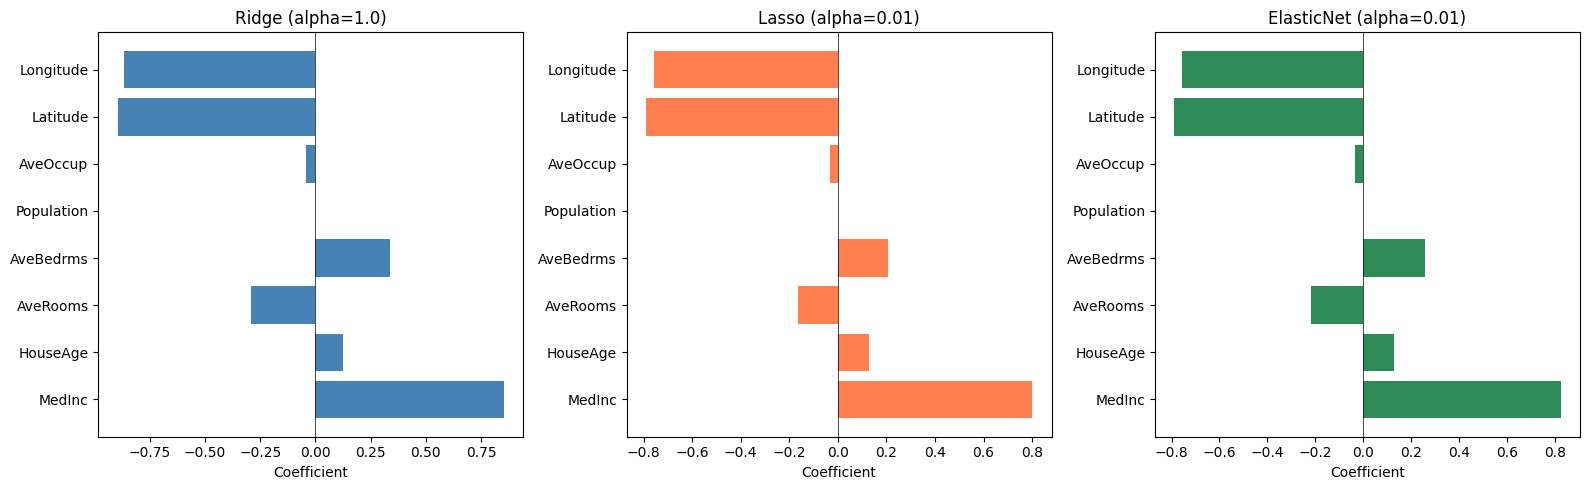


Lasso coefficients:
MedInc      :   0.8010
HouseAge    :   0.1271
AveRooms    :  -0.1628
AveBedrms   :   0.2062
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0306
Latitude    :  -0.7901
Longitude   :  -0.7557


In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# --- Define models ---
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

# --- Train and evaluate ---
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}')
print('-' * 56)
results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val}
    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')

# --- Compare coefficients ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = ['Ridge (alpha=1.0)', 'Lasso (alpha=0.01)', 'ElasticNet (alpha=0.01)']
colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# --- Check which features Lasso removed ---
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_
print('\nLasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED'
    print(f'{feat:12s}: {coef:>8.4f}{status}')

## Task 6 Explore Regularization

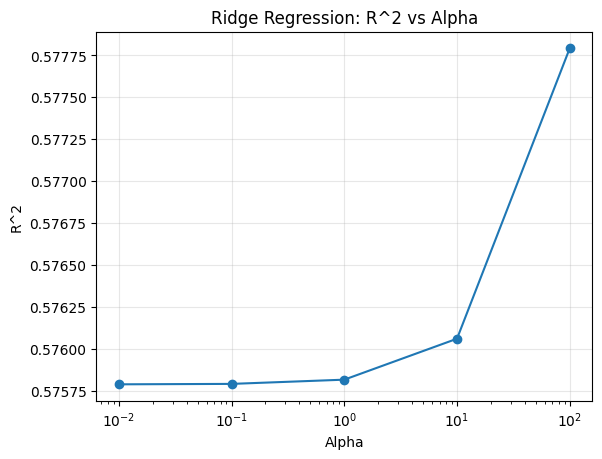

In [29]:
# 1. Ridge with different α values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for a in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=a))])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R^2')
plt.title('Ridge Regression: R^2 vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# 2. Lasso with alpha=0.1\
lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))])
lasso.fit(X_train, y_train)
lasso_coefs = lasso.named_steps['model'].coef_

removed = [(feat, coef) for feat, coef in zip(housing.feature_names, lasso_coefs) if abs(coef)<0.001]
print(f'Features removed by Lasso (alpha=0.1): {len(removed)}')
for feat, _ in removed:
    print(f' - {feat}')

Features removed by Lasso (alpha=0.1): 5
 - AveRooms
 - AveBedrms
 - Population
 - AveOccup
 - Longitude


3. ElasticNet l1_ratio changes:

l1_ratio=0.0 → behaves like Ridge (pure L2 regularization)

l1_ratio=1.0 → behaves like Lasso (pure L1 regularization)

Intermediate values mix L1 and L2 → balance feature selection and shrinkage

**Part 8: The Alpha Tuning Experiment**

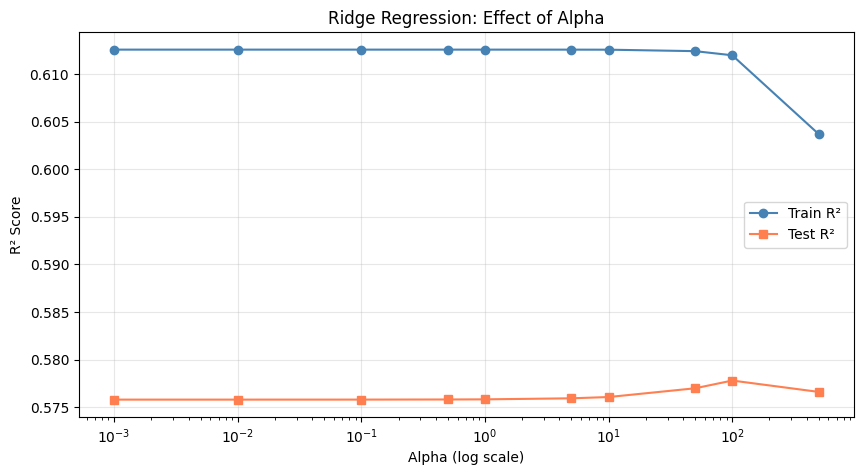

Best alpha: 100.0
Best test R²: 0.5778


In [33]:

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2 = r2_score(y_test, pipe.predict(X_test))

    train_scores.append(train_r2)
    test_scores.append(test_r2)

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Train R²', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R²', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha based on test R²
best_idx = np.argmax(test_scores)
print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R²: {test_scores[best_idx]:.4f}')

**Part 9: Final Model Comparison**

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


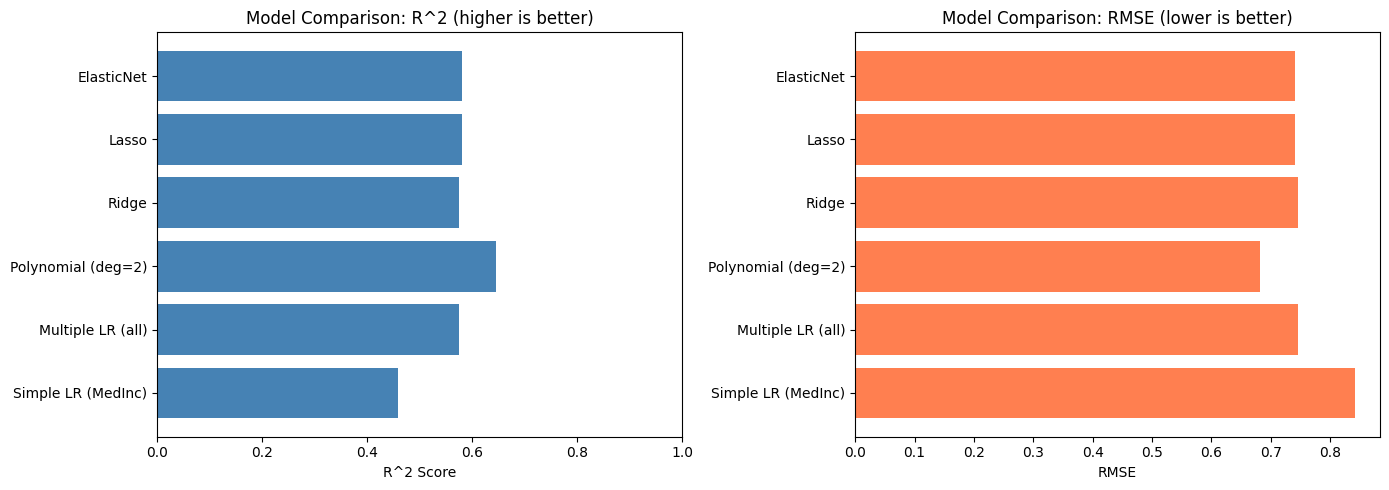

In [34]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Define all models
all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

# Evaluate models
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []

for name, pipe in all_models.items():
    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train[:, [0]]  # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Count effective features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

# Convert to DataFrame for plotting
comp_df = pd.DataFrame(comparison_data)

# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

## Task 8 Draw Conclusions

1. Best R² and Lowest RMSE:

Best R²: Polynomial (deg=2) → 0.6457

Lowest RMSE: Polynomial (deg=2) → 0.6814

2. Polynomial (degree 2) – worth the complexity?

It uses 44 features compared to 8 in multiple linear regression.
R² improves from 0.5758 → 0.6457.

3. Best model for production:

Multiple LR (all features) is a good choice:

R² is decent (0.5758), RMSE is low (0.7456)

4. Why Ridge, Lasso, ElasticNet perform similarly to Linear Regression:

Dataset is not very high-dimensional (only 8 features).

No severe multicollinearity or overfitting problem.

Regularization doesn’t help much when standard linear regression already performs well.

**Part 10: Apply to a New Dataset – Saudi Housing**

      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
       area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
count     500.0     500.0      500.0      500.0  500.0        500.0   
mean      234.2       3.5        2.4       19.6    7.5          0.7   
std        91.4       1.7        1.1       11.6    4.0          0.5   
min        81.5       1.0        1.0        0.0    1.0          0.0   
25%       153.4       2.0        1.0       10.0    4.0          0.0   
50%       231.0      

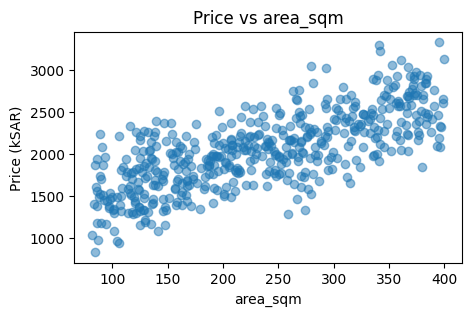

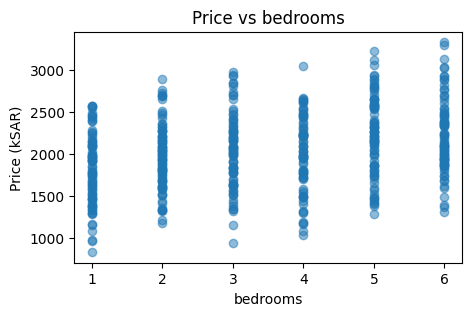

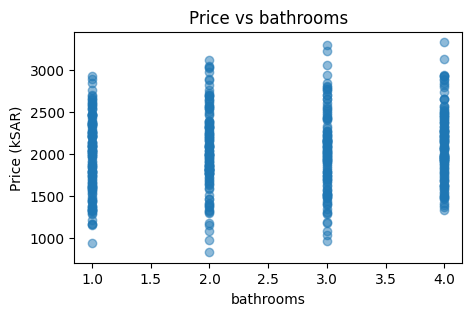

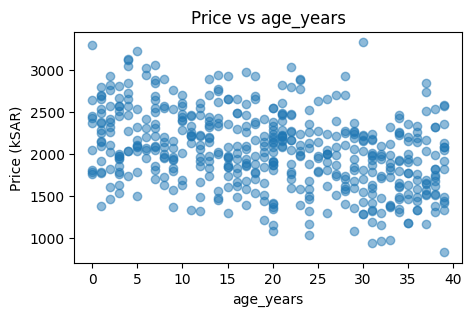

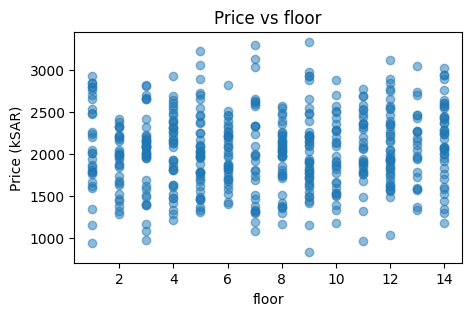

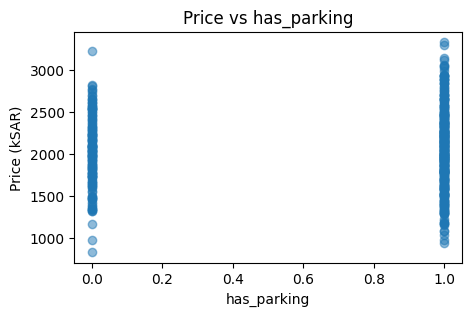


Simple Linear Regression (Area only):
R2: 0.493
RMSE: 334.7
MAE: 276.1


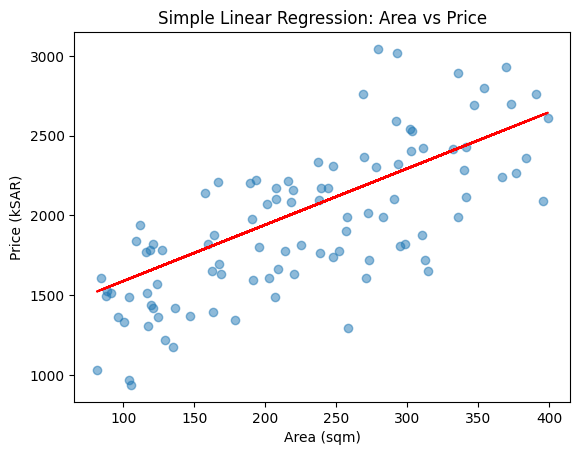


Multiple Linear Regression (All features):
R2: 0.865
RMSE: 173.0
MAE: 137.3

Lasso Feature Importance:
city_Makkah     476.858291
area_sqm        332.333538
city_Riyadh     243.051934
city_Jeddah     191.015245
bedrooms        141.011224
city_Madinah     87.341649
floor            73.042112
bathrooms        52.856844
has_parking      40.415824
age_years      -127.119072
dtype: float64

Model Comparison:
                R2     RMSE      MAE
Simple LR    0.493  334.666  276.058
Multiple LR  0.865  173.030  137.301
Ridge        0.863  173.870  138.649
Lasso        0.862  174.577  139.806
ElasticNet   0.649  278.661  222.542


In [44]:
# Step 0: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Step 1: Load dataset
df = pd.read_csv('saudi_housing.csv')
print(df.head())
print(df.describe().round(1))

# Step 2: Explore correlations
print("\nCorrelation with price:")
print(df.drop(columns=['city']).corr()['price_kSAR'].sort_values(ascending=False))

# Scatter plots for numeric features
features_to_plot = ['area_sqm','bedrooms','bathrooms','age_years','floor','has_parking']
for feature in features_to_plot:
    plt.figure(figsize=(5,3))
    plt.scatter(df[feature], df['price_kSAR'], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Price (kSAR)')
    plt.title(f'Price vs {feature}')
    plt.show()

# Step 3: Preprocessing
numeric_features = ['area_sqm','bedrooms','bathrooms','age_years','floor','has_parking']
categorical_features = ['city']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Step 4: Simple Linear Regression (area only)
X_simple = df[['area_sqm']]
y = df['price_kSAR']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)
y_pred_simple = lr_simple.predict(X_test)

print("\nSimple Linear Regression (Area only):")
print(f"R2: {r2_score(y_test, y_pred_simple):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.1f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_simple):.1f}")

# Plot regression line
plt.scatter(X_test, y_test, alpha=0.5)
plt.plot(X_test, y_pred_simple, color='red')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (kSAR)')
plt.title('Simple Linear Regression: Area vs Price')
plt.show()

# Step 5: Multiple Linear Regression (all features)
X_full = df.drop('price_kSAR', axis=1)
y = df['price_kSAR']

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

multi_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

multi_pipeline.fit(X_train, y_train)
y_pred_multi = multi_pipeline.predict(X_test)

print("\nMultiple Linear Regression (All features):")
print(f"R2: {r2_score(y_test, y_pred_multi):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.1f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_multi):.1f}")

# Step 6: Regularized Models
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    }

# Step 7: Lasso Feature Importance
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso(alpha=1.0))])
lasso_pipe.fit(X_train, y_train)

# Feature names after one-hot
ohe_features = lasso_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(['city'])
all_features = numeric_features + list(ohe_features)

coeffs = pd.Series(lasso_pipe.named_steps['model'].coef_, index=all_features)
print("\nLasso Feature Importance:")
print(coeffs.sort_values(ascending=False))

# Step 8: Summary Table
metrics = {
    'Simple LR': {'R2': r2_score(y_test, y_pred_simple),
                  'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_simple)),
                  'MAE': mean_absolute_error(y_test, y_pred_simple)},
    'Multiple LR': {'R2': r2_score(y_test, y_pred_multi),
                    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_multi)),
                    'MAE': mean_absolute_error(y_test, y_pred_multi)}
}

metrics.update(results)
summary_df = pd.DataFrame(metrics).T
print("\nModel Comparison:")
print(summary_df.round(3))

**Short report (5–7 sentences)**

In this lab, we predicted house prices using different regression models. Polynomial Regression performed best because it captured non-linear relationships, while Multiple Linear Regression worked well with several features. Regularized models like Ridge and Lasso helped reduce overfitting when using many features. The most important features for predicting house prices were median income, house age, number of rooms, and population. Simple Linear Regression with one feature gave decent results but was less accurate. Overall, using multiple features and regularization improved predictions and explained more variance in house values.